# Character-Level Encoder-Decoder Transformer

## Setup

In [ ]:
!pip install einops -q

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange
import matplotlib.pyplot as plt
import urllib.request
import os

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## Data

In [13]:
URL = "https://ocw.mit.edu/ans7870/6/6.006/s08/lecturenotes/files/t8.shakespeare.txt"

if not os.path.exists('shakespeare.txt'):
    urllib.request.urlretrieve(URL, 'shakespeare.txt')

with open('shakespeare.txt', 'r') as f:
    text = f.read()

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}

BOS = vocab_size
vocab_size_with_bos = vocab_size + 1

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l if i in itos])

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f'Vocab size: {vocab_size} (+1 BOS = {vocab_size_with_bos})')
print(f'Train: {len(train_data)} | Val: {len(val_data)}')

Vocab size: 91 (+1 BOS = 92)
Train: 4912379 | Val: 545820


## Hyperparameters

In [18]:
BATCH_SIZE = 64
SRC_LEN = 128
TGT_LEN = 128
D_MODEL = 192
N_HEADS = 6
N_ENC_LAYERS = 3
N_DEC_LAYERS = 3
DROPOUT = 0.1
LR = 3e-4
MAX_ITERS = 2000
EVAL_INTERVAL = 200
EVAL_ITERS = 100

## Batching

In [15]:
def get_batch(split):
    d = train_data if split == 'train' else val_data
    total_len = SRC_LEN + TGT_LEN
    ix = torch.randint(len(d) - total_len, (BATCH_SIZE,))

    src = torch.stack([d[i:i+SRC_LEN] for i in ix])
    tgt_full = torch.stack([d[i+SRC_LEN:i+total_len] for i in ix])

    bos_col = torch.full((BATCH_SIZE, 1), BOS, dtype=torch.long)
    tgt_in = torch.cat([bos_col, tgt_full[:, :-1]], dim=1)
    tgt_out = tgt_full

    return src.to(DEVICE), tgt_in.to(DEVICE), tgt_out.to(DEVICE)

## Model

In [16]:
class SelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout, causal=False):
        super().__init__()
        self.n_heads = n_heads
        self.causal = causal
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

    def forward(self, x):
        qkv = self.qkv(x)
        q, k, v = rearrange(qkv, 'b t (three h d) -> three b h t d', three=3, h=self.n_heads).unbind(0)
        scale = q.size(-1) ** -0.5
        attn = torch.matmul(q, k.transpose(-2, -1)) * scale

        if self.causal:
            T = x.size(1)
            mask = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
            attn = attn.masked_fill(mask, float('-inf'))

        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)
        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h t d -> b t (h d)')
        return self.resid_drop(self.out_proj(out))


class CrossAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.n_heads = n_heads
        self.wq = nn.Linear(d_model, d_model)
        self.wkv = nn.Linear(d_model, 2 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

    def forward(self, x, enc_out):
        q = rearrange(self.wq(x), 'b t (h d) -> b h t d', h=self.n_heads)
        kv = self.wkv(enc_out)
        k, v = rearrange(kv, 'b s (two h d) -> two b h s d', two=2, h=self.n_heads).unbind(0)

        scale = q.size(-1) ** -0.5
        attn = torch.matmul(q, k.transpose(-2, -1)) * scale
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)
        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h t d -> b t (h d)')
        return self.resid_drop(self.out_proj(out))


class FeedForward(nn.Module):
    def __init__(self, d_model, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class EncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.self_attn = SelfAttention(d_model, n_heads, dropout, causal=False)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, dropout)

    def forward(self, x):
        x = x + self.self_attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.self_attn = SelfAttention(d_model, n_heads, dropout, causal=True)
        self.ln2 = nn.LayerNorm(d_model)
        self.cross_attn = CrossAttention(d_model, n_heads, dropout)
        self.ln3 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, dropout)

    def forward(self, x, enc_out):
        x = x + self.self_attn(self.ln1(x))
        x = x + self.cross_attn(self.ln2(x), enc_out)
        x = x + self.ff(self.ln3(x))
        return x


class EncoderDecoderTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_enc_layers, n_dec_layers, src_len, tgt_len, dropout):
        super().__init__()
        self.src_len = src_len
        self.tgt_len = tgt_len

        self.enc_tok_emb = nn.Embedding(vocab_size, d_model)
        self.enc_pos_emb = nn.Embedding(src_len, d_model)
        self.enc_drop = nn.Dropout(dropout)
        self.encoder = nn.ModuleList([EncoderBlock(d_model, n_heads, dropout) for _ in range(n_enc_layers)])
        self.enc_ln = nn.LayerNorm(d_model)

        self.dec_tok_emb = nn.Embedding(vocab_size, d_model)
        self.dec_pos_emb = nn.Embedding(tgt_len, d_model)
        self.dec_drop = nn.Dropout(dropout)
        self.decoder = nn.ModuleList([DecoderBlock(d_model, n_heads, dropout) for _ in range(n_dec_layers)])
        self.dec_ln = nn.LayerNorm(d_model)

        self.head = nn.Linear(d_model, vocab_size - 1)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def encode(self, src):
        B, S = src.shape
        tok = self.enc_tok_emb(src)
        pos = self.enc_pos_emb(torch.arange(S, device=src.device))
        x = self.enc_drop(tok + pos)
        for block in self.encoder:
            x = block(x)
        return self.enc_ln(x)

    def decode(self, tgt, enc_out):
        B, T = tgt.shape
        tok = self.dec_tok_emb(tgt)
        pos = self.dec_pos_emb(torch.arange(T, device=tgt.device))
        x = self.dec_drop(tok + pos)
        for block in self.decoder:
            x = block(x, enc_out)
        x = self.dec_ln(x)
        return self.head(x)

    def forward(self, src, tgt_in, tgt_out=None):
        enc_out = self.encode(src)
        logits = self.decode(tgt_in, enc_out)

        loss = None
        if tgt_out is not None:
            loss = F.cross_entropy(
                rearrange(logits, 'b t c -> (b t) c'),
                rearrange(tgt_out, 'b t -> (b t)')
            )
        return logits, loss

model = EncoderDecoderTransformer(
    vocab_size_with_bos, D_MODEL, N_HEADS, N_ENC_LAYERS, N_DEC_LAYERS, SRC_LEN, TGT_LEN, DROPOUT
).to(DEVICE)

print(f'Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M')

Parameters: 3.22M


## Training

In [19]:
@torch.no_grad()
def estimate_loss(model):
    model.eval()
    out = {}
    for split in ['train', 'val']:
        losses = torch.zeros(EVAL_ITERS)
        for k in range(EVAL_ITERS):
            src, tgt_in, tgt_out = get_batch(split)
            _, loss = model(src, tgt_in, tgt_out)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [20]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
history = {'step': [], 'train_loss': [], 'val_loss': []}

for step in range(MAX_ITERS):
    if step % EVAL_INTERVAL == 0 or step == MAX_ITERS - 1:
        losses = estimate_loss(model)
        history['step'].append(step)
        history['train_loss'].append(losses['train'])
        history['val_loss'].append(losses['val'])
        print(f"step {step:5d} | train {losses['train']:.4f} | val {losses['val']:.4f}")

    src, tgt_in, tgt_out = get_batch('train')
    _, loss = model(src, tgt_in, tgt_out)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step     0 | train 4.6435 | val 4.6455
step   200 | train 2.4361 | val 2.4489
step   400 | train 2.2142 | val 2.2269
step   600 | train 2.0484 | val 2.0573
step   800 | train 1.9191 | val 1.9371
step  1000 | train 1.8104 | val 1.8312
step  1200 | train 1.7313 | val 1.7536
step  1400 | train 1.6546 | val 1.6947
step  1600 | train 1.5931 | val 1.6335
step  1800 | train 1.5395 | val 1.5919
step  1999 | train 1.4999 | val 1.5664


## Loss Plot

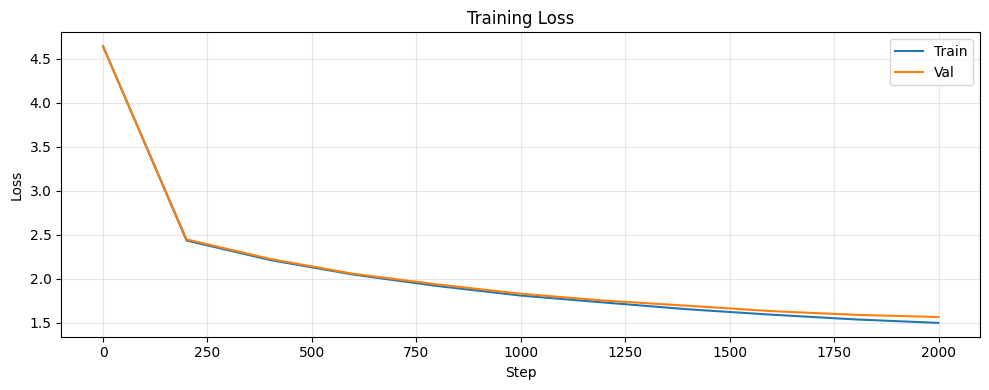

In [21]:
def plot_loss(history):
    plt.figure(figsize=(10, 4))
    plt.plot(history['step'], history['train_loss'], label='Train')
    plt.plot(history['step'], history['val_loss'], label='Val')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_loss(history)

## Generator

In [22]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=500, temperature=0.8, top_k=None):
    model.eval()
    src = torch.tensor([encode(prompt)], dtype=torch.long, device=DEVICE)
    if src.size(1) > model.src_len:
        src = src[:, -model.src_len:]

    enc_out = model.encode(src)

    idx = torch.full((1, 1), BOS, dtype=torch.long, device=DEVICE)

    generated = []
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.tgt_len:]
        logits = model.decode(idx_cond, enc_out)
        logits = logits[:, -1, :] / temperature

        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = float('-inf')

        probs = F.softmax(logits, dim=-1)
        next_tok = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_tok], dim=1)
        generated.append(next_tok.item())

    return prompt + decode(generated)

In [23]:
prompt = 'ROMEO:\nO, she doth teach the torches to burn bright!\n'
print(generate(model, prompt, max_new_tokens=500, temperature=0.8, top_k=40))

ROMEO:
O, she doth teach the torches to burn bright!
     Shall before live,
    Burk in the eady profest, and of not know
    As great her me nobs of sair'ds,
    Why this wong in brit the fears of Sirate.
                                            Exeunt A Swargs;
    The wors accous a lasong my soul
    Have not of me in thing. My love, be me mine.
    The will this trank to stady to know with dear of the
    hour pleatse of this this frefore stirs,
    The to one than fliends the lays.
    You will pray you desence the Conful dear,
    Is hav
